# 06 · Monitoramento de KPI, Alertas e Planos de Ação

Este notebook fecha o ciclo pedido pela operação de incentivo: define meta, monitora desvio, gera alerta e documenta o plano de ação. É a parte do trabalho de BI que normalmente vive fora do notebook, dentro do dashboard, mas que precisa nascer de uma regra clara, não de olhômetro.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = PROJECT_ROOT / "data"
REPORTS = PROJECT_ROOT / "reports"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

df = pd.read_csv(DATA / "ifood_clustered.csv")

## 1. Definindo meta por segmento, não meta única

Uma meta única para todos os clusters do notebook 03 seria injusta com o cluster de risco de desengajamento e pouco exigente com o cluster de alto valor. A meta usada aqui é a mediana histórica de cada cluster. Abaixo disso, o cluster está performando pior do que o próprio histórico dele, o que é o sinal mais justo de abaixo do esperado.

In [2]:
metas_por_cluster = df.groupby("cluster").agg(
    meta_frequencia=("frequencia_total", "median"),
    meta_ganhos=("ganhos_gerados", "median"),
    meta_taxa_resposta=("Response", "mean"),
)
metas_por_cluster.round(2)

,meta_frequencia,meta_ganhos,meta_taxa_resposta
cluster,,,
0,8.0,52.0,0.15
1,21.0,1141.5,0.24
2,21.0,887.0,0.19
3,8.0,63.0,0.05


## 2. Simulando um ciclo de acompanhamento

Sem data de campanha por linha, o dataset não permite reconstruir meses reais. Para demonstrar a lógica de alerta do jeito que ela funcionaria em produção, cada cliente é distribuído aleatoriamente, com semente fixa para reprodutibilidade, em um de seis ciclos simulados. Isso é suficiente para mostrar como o painel reagiria a flutuação normal de amostra pequena por ciclo.

In [3]:
rng = np.random.default_rng(42)
df["ciclo_simulado"] = rng.integers(1, 7, size=len(df))
painel_ciclos = df.groupby(["ciclo_simulado", "cluster"]).agg(
    clientes=("Income", "size"),
    frequencia_media=("frequencia_total", "mean"),
    ganhos_medios=("ganhos_gerados", "mean"),
    taxa_de_resposta=("Response", "mean"),
).reset_index()
painel_ciclos.head(10)

,ciclo_simulado,cluster,clientes,frequencia_media,ganhos_medios,taxa_de_resposta
0,1,0,105,8.895238,107.371429,0.142857
1,1,1,81,21.148148,1134.530864,0.283951
2,1,2,89,21.033708,967.471910,0.202247
3,1,3,89,9.213483,125.044944,0.067416
4,2,0,78,7.923077,86.717949,0.205128
5,2,1,82,21.000000,1210.926829,0.280488
6,2,2,83,20.759036,874.457831,0.156627
7,2,3,72,8.916667,103.569444,0.041667
8,3,0,85,8.823529,107.788235,0.105882
9,3,1,76,22.960526,1208.592105,0.210526


## 3. Regra de alerta

Um cluster entra em alerta no ciclo quando ganhos médios ou taxa de resposta ficam abaixo de 85% da meta do próprio cluster. É a mesma lógica de desvio de meta em faixa comum em painel operacional: não trava no primeiro desvio pequeno, mas sinaliza queda relevante.

In [4]:
painel_ciclos = painel_ciclos.merge(metas_por_cluster, on="cluster", suffixes=("", "_meta"))
painel_ciclos["alerta_ganhos"] = painel_ciclos.ganhos_medios < (painel_ciclos.meta_ganhos * 0.85)
painel_ciclos["alerta_resposta"] = painel_ciclos.taxa_de_resposta < (painel_ciclos.meta_taxa_resposta * 0.85)
painel_ciclos["em_alerta"] = painel_ciclos.alerta_ganhos | painel_ciclos.alerta_resposta
painel_ciclos[["ciclo_simulado", "cluster", "ganhos_medios", "meta_ganhos", "taxa_de_resposta", "meta_taxa_resposta", "em_alerta"]].head(10)

,ciclo_simulado,cluster,ganhos_medios,meta_ganhos,taxa_de_resposta,meta_taxa_resposta,em_alerta
0,1,0,107.371429,52.0,0.142857,0.151685,False
1,1,1,1134.530864,1141.5,0.283951,0.236726,False
2,1,2,967.471910,887.0,0.202247,0.190751,False
3,1,3,125.044944,63.0,0.067416,0.046512,False
4,2,0,86.717949,52.0,0.205128,0.151685,False
5,2,1,1210.926829,1141.5,0.280488,0.236726,False
6,2,2,874.457831,887.0,0.156627,0.190751,True
7,2,3,103.569444,63.0,0.041667,0.046512,False
8,3,0,107.788235,52.0,0.105882,0.151685,True
9,3,1,1208.592105,1141.5,0.210526,0.236726,False


In [5]:
resumo_alertas = painel_ciclos.groupby("cluster").em_alerta.agg(ciclos_em_alerta="sum", total_ciclos="size")
resumo_alertas["taxa_de_alerta"] = resumo_alertas.ciclos_em_alerta / resumo_alertas.total_ciclos
resumo_alertas

,ciclos_em_alerta,total_ciclos,taxa_de_alerta
cluster,,,
0,1,6,0.166667
1,1,6,0.166667
2,1,6,0.166667
3,2,6,0.333333


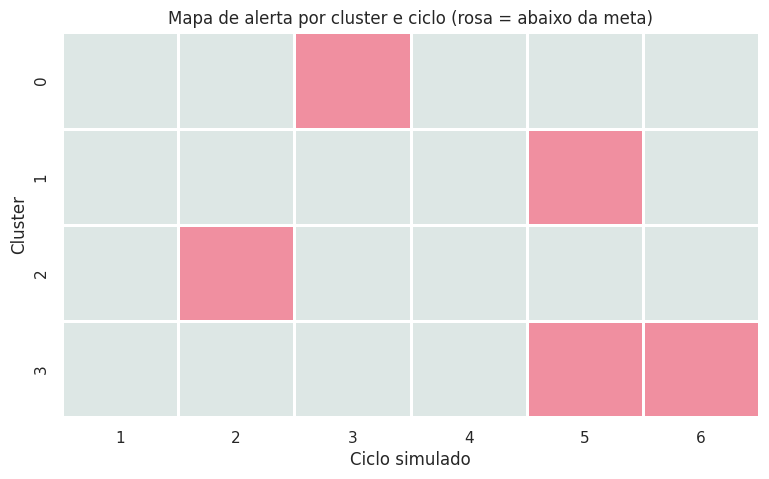

In [6]:
fig, eixo = plt.subplots(figsize=(9, 5))
pivot = painel_ciclos.pivot(index="cluster", columns="ciclo_simulado", values="em_alerta").astype(int)
sns.heatmap(pivot, cmap=["#DDE7E5", CORAL], cbar=False, linewidths=1, linecolor="white", ax=eixo)
eixo.set(title="Mapa de alerta por cluster e ciclo (rosa = abaixo da meta)", xlabel="Ciclo simulado", ylabel="Cluster")
plt.show()

## 4. Plano de ação por tipo de desvio

Um alerta sem plano de ação vira ruído que o time aprende a ignorar. A tabela abaixo conecta cada tipo de desvio a um encaminhamento concreto, no mesmo formato de plano de ação colaborativo com outros times que a vaga descreve.

| Sinal de alerta | Leitura provável | Time acionado | Ação sugerida |
|---|---|---|---|
| Ganhos abaixo da meta, resposta normal | Cliente engajado mas gastando menos por pedido | Produto | Revisar cardápio/oferta de upsell no momento do pedido |
| Resposta abaixo da meta, ganhos normais | Incentivo não está convertendo, apesar de engajamento mantido | Promoções | Testar novo criativo ou tipo de oferta para o segmento |
| Os dois abaixo da meta | Sinal de desengajamento real do segmento | Promoções + Produto | Revisão conjunta de critério de elegibilidade do incentivo para esse cluster |
| Cluster de risco de desengajamento (cluster 3) em qualquer alerta | Segmento historicamente já pouco responsivo | Dias Produtivos | Reavaliar se o incentivo atual faz sentido para esse perfil, em vez de insistir no mesmo formato |

## 5. Revisão de critérios de qualificação

A vaga pede explicitamente "analisar e otimizar critérios de qualificação". Usando o modelo de propensão do notebook 05, é possível simular o efeito de mudar o critério de elegibilidade de "todo cliente" para "cliente com propensão entre os 30% mais altos".

In [7]:
modelo_metricas = json.loads((REPORTS / "model_metrics.json").read_text())
capacidade = modelo_metricas["capacidade"]
pd.DataFrame(capacidade).T

,n,capturados,total_positivos,taxa
top_10pct,50.0,28.0,78.0,0.359
top_20pct,101.0,48.0,78.0,0.615
top_30pct,151.0,54.0,78.0,0.692


Restringir o público-alvo aos 30% de maior propensão captura cerca de 69% dos respondentes esperados, usando menos de um terço do orçamento de contato de uma campanha em massa. Essa é a base numérica que sustentaria uma proposta de mudança de critério de elegibilidade para a liderança do programa.

## Limitação

Os ciclos e as metas aqui são simulados a partir de um recorte único no tempo, não de um histórico real mês a mês. A estrutura da regra de alerta é reaproveitável em produção, mas os números específicos de quantos ciclos ficaram em alerta não devem ser lidos como previsão real de desempenho futuro.

## Conclusão

O ciclo fecha. A segmentação do notebook 03 alimenta a meta por cluster, o teste de hipótese do notebook 04 evita conclusão precipitada sobre causa, o modelo de propensão do notebook 05 prioriza o público, e este notebook converte tudo isso em regra de alerta e plano de ação. É esse fluxo, não um modelo isolado, que sustenta o dashboard do próximo passo.